In [ ]:
# ============================================================
# CIC-IDS2017 RandomForest Training - Google Colab
# ============================================================

import os
import glob
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

warnings.filterwarnings("ignore")

In [ ]:
# ============================================================
# 1. Mount Google Drive
# ============================================================

drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/CICIDS2017"

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

print("Number of CSV files:", len(csv_files))
for file in csv_files:
    print(file)

Mounted at /content/drive
Number of CSV files: 8
/content/drive/MyDrive/CICIDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/content/drive/MyDrive/CICIDS2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/content/drive/MyDrive/CICIDS2017/Friday-WorkingHours-Morning.pcap_ISCX.csv
/content/drive/MyDrive/CICIDS2017/Monday-WorkingHours.pcap_ISCX.csv
/content/drive/MyDrive/CICIDS2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/content/drive/MyDrive/CICIDS2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/content/drive/MyDrive/CICIDS2017/Tuesday-WorkingHours.pcap_ISCX.csv
/content/drive/MyDrive/CICIDS2017/Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
# ============================================================
# 2. Load all CSV files
# ============================================================

dfs = []

for file in csv_files:
    print("Loading:", os.path.basename(file))
    df_temp = pd.read_csv(file, low_memory=False)

    # Xóa khoảng trắng trong tên cột
    df_temp.columns = df_temp.columns.str.strip()

    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df["Label"].value_counts())

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Dataset shape: (2830743, 79)
Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',

In [ ]:
# ============================================================
# 3. Basic cleaning
# ============================================================

# Xóa dòng trùng lặp nếu có
df = df.drop_duplicates()

# Xóa khoảng trắng trong nhãn
df["Label"] = df["Label"].astype(str).str.strip()

# Chuẩn hóa lỗi ký tự trong Web Attack
df["Label"] = df["Label"].str.replace("Web Attack �", "Web Attack", regex=False)

print("After cleaning:", df.shape)
print(df["Label"].value_counts())

After cleaning: (2522362, 79)
Label
BENIGN                      2096484
DoS Hulk                     172849
DDoS                         128016
PortScan                      90819
DoS GoldenEye                 10286
FTP-Patator                    5933
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
Bot                            1953
Web Attack Brute Force         1470
Web Attack XSS                  652
Infiltration                     36
Web Attack Sql Injection         21
Heartbleed                       11
Name: count, dtype: int64


In [ ]:
# ============================================================
# 4. Chọn chế độ train: binary hoặc multiclass
# ============================================================

# TASK = "binary"      # BENIGN vs ATTACK
TASK = "multiclass"   # BENIGN, DDoS, PortScan, DoS Hulk, Bot, ...

label_col = "Label"

X = df.drop(columns=[label_col])
y_raw = df[label_col]

# Ép toàn bộ feature sang dạng số
X = X.apply(pd.to_numeric, errors="coerce")

# Thay inf, -inf bằng NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Chuyển về float32 để giảm RAM
X = X.astype("float32")

if TASK == "binary":
    y = y_raw.apply(lambda x: "BENIGN" if x == "BENIGN" else "ATTACK")
else:
    y = y_raw.copy()

print("Task:", TASK)
print(y.value_counts())

Task: multiclass
Label
BENIGN                      2096484
DoS Hulk                     172849
DDoS                         128016
PortScan                      90819
DoS GoldenEye                 10286
FTP-Patator                    5933
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
Bot                            1953
Web Attack Brute Force         1470
Web Attack XSS                  652
Infiltration                     36
Web Attack Sql Injection         21
Heartbleed                       11
Name: count, dtype: int64


In [ ]:
# ============================================================
# 6. Encode label
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Classes:
0 -> BENIGN
1 -> Bot
2 -> DDoS
3 -> DoS GoldenEye
4 -> DoS Hulk
5 -> DoS Slowhttptest
6 -> DoS slowloris
7 -> FTP-Patator
8 -> Heartbleed
9 -> Infiltration
10 -> PortScan
11 -> SSH-Patator
12 -> Web Attack Brute Force
13 -> Web Attack Sql Injection
14 -> Web Attack XSS


In [ ]:
# ============================================================
# 7. Train/Test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (2017889, 78)
X_test: (504473, 78)


In [ ]:
# ============================================================
# 8. Handle missing values
# ============================================================

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Missing values handled.")

Missing values handled.


In [ ]:
# ============================================================
# 9. Train RandomForest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_time = time.time()

rf_model.fit(X_train_imputed, y_train)

train_time = time.time() - start_time

print(f"Training time: {train_time:.2f} seconds")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  7.7min


Training time: 974.36 seconds


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 16.2min finished


In [ ]:
# ============================================================
# 10. Evaluate model
# ============================================================

start_time = time.time()

y_pred = rf_model.predict(X_test_imputed)

test_time = time.time() - start_time

accuracy = accuracy_score(y_test, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("========== Evaluation Results ==========")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")
print(f"Weighted F1-score: {f1_weighted:.4f}")
print(f"Prediction time: {test_time:.2f} seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    3.2s


========== Evaluation Results ==========
Accuracy: 0.9983
Macro Precision: 0.9352
Macro Recall: 0.8878
Macro F1-score: 0.9080
Weighted Precision: 0.9982
Weighted Recall: 0.9983
Weighted F1-score: 0.9982
Prediction time: 6.91 seconds

Classification Report:
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    419297
                     Bot       0.89      0.77      0.83       391
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       1.00      0.99      0.99      2057
                DoS Hulk       1.00      1.00      1.00     34570
        DoS Slowhttptest       0.99      0.99      0.99      1046
           DoS slowloris       1.00      0.99      1.00      1077
             FTP-Patator       1.00      1.00      1.00      1187
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       1.00      0.71      0.83         7
                

[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    6.8s finished


<Figure size 1200x1000 with 0 Axes>

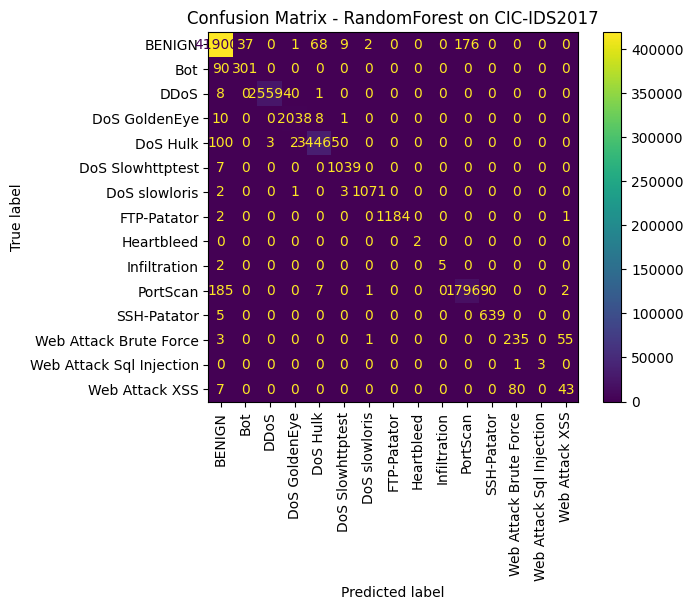

In [ ]:
# ============================================================
# 11. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(xticks_rotation=90, values_format="d")
plt.title("Confusion Matrix - RandomForest on CIC-IDS2017")
plt.show()

                        Feature  Importance
0              Destination Port    0.057502
67      Init_Win_bytes_backward    0.044759
35            Bwd Header Length    0.027870
52          Average Packet Size    0.026090
1                 Flow Duration    0.025871
17                 Flow IAT Std    0.025848
39            Max Packet Length    0.025264
37                Bwd Packets/s    0.025006
6         Fwd Packet Length Max    0.024983
54         Avg Bwd Segment Size    0.024431
5   Total Length of Bwd Packets    0.023985
66       Init_Win_bytes_forward    0.023878
21                 Fwd IAT Mean    0.023829
10        Bwd Packet Length Max    0.023751
15               Flow Packets/s    0.023213
16                Flow IAT Mean    0.022434
69         min_seg_size_forward    0.020961
40           Packet Length Mean    0.020740
65            Subflow Bwd Bytes    0.019736
23                  Fwd IAT Max    0.019621


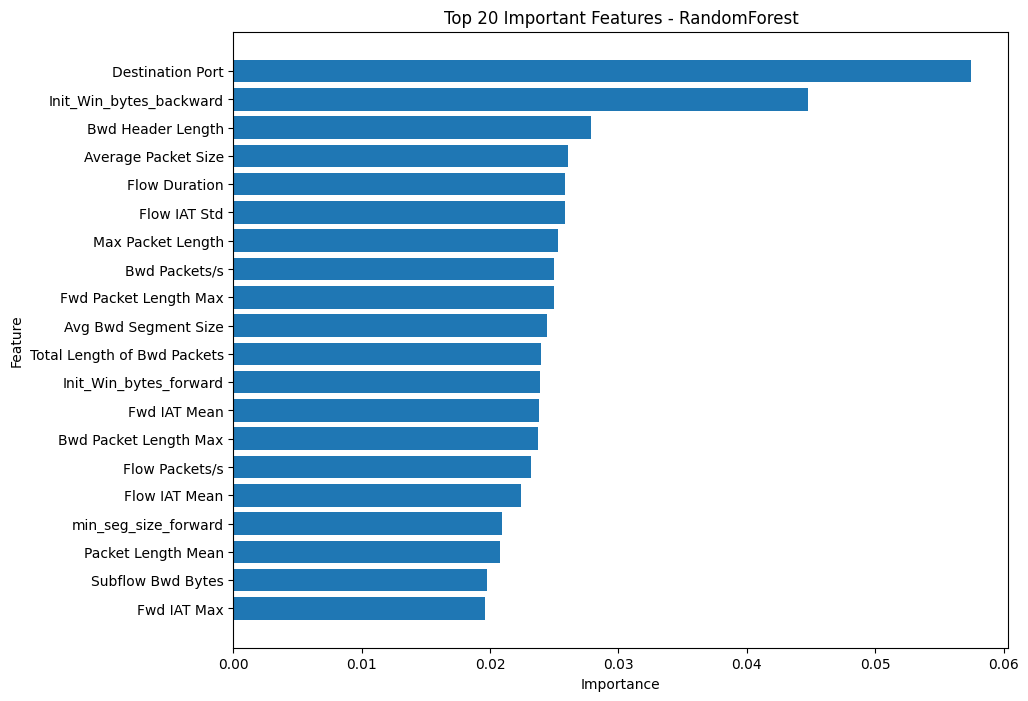

In [ ]:
# ============================================================
# 12. Feature Importance
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance["Feature"].head(20)[::-1],
    feature_importance["Importance"].head(20)[::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features - RandomForest")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model.fit(X_train_scaled, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 13.4min finished


RandomForestClassifier(class_weight='balanced_subsample', n_jobs=-1,
                       random_state=42, verbose=1)

In [ ]:
# ============================================================
# 13. Save model
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/CICIDS2017_RF_Model_Full"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(rf_model, os.path.join(SAVE_DIR, "random_forest_model.pkl"))
joblib.dump(imputer, os.path.join(SAVE_DIR, "imputer.pkl"))
joblib.dump(label_encoder, os.path.join(SAVE_DIR, "label_encoder.pkl"))
joblib.dump(list(X.columns), os.path.join(SAVE_DIR, "feature_names.pkl"))
joblib.dump(scaler, "scaler.pkl")

print("Model saved to:", SAVE_DIR)

Model saved to: /content/drive/MyDrive/CICIDS2017_RF_Model_Full


In [ ]:
# ============================================================
# Load saved model and predict sample
# ============================================================

rf_model = joblib.load("/content/drive/MyDrive/CICIDS2017_RF_Model_Full/random_forest_model.pkl")
imputer = joblib.load("/content/drive/MyDrive/CICIDS2017_RF_Model_Full/imputer.pkl")
label_encoder = joblib.load("/content/drive/MyDrive/CICIDS2017_RF_Model_Full/label_encoder.pkl")
feature_names = joblib.load("/content/drive/MyDrive/CICIDS2017_RF_Model_Full/feature_names.pkl")
scaler = joblib.load("/content/drive/MyDrive/CICIDS2017_RF_Model_Full/scaler.pkl")
sample = X_test.iloc[:10]
sample_imputed = imputer.transform(sample)

pred = rf_model.predict(sample_imputed)
pred_label = label_encoder.inverse_transform(pred)

print(pred_label)

['BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN'
 'BENIGN' 'BENIGN']


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


In [ ]:
# Tạo file CSV mẫu để test trên Streamlit
sample = X_test.copy()
sample["Label"] = y_test.values if hasattr(y_test, "values") else y_test

# Lấy 50 dòng đầu để demo
sample_traffic = sample.head(50)

sample_traffic.to_csv("sample_traffic.csv", index=False)

print("Created sample_traffic.csv successfully!")
print(sample_traffic.head())

Created sample_traffic.csv successfully!
         Destination Port  Flow Duration  Total Fwd Packets  \
33409                80.0      5011280.0                5.0   
2695710              80.0        23354.0                1.0   
813114            58480.0       245295.0                2.0   
779382            52987.0           27.0                2.0   
1538262              80.0        69910.0                4.0   

         Total Backward Packets  Total Length of Fwd Packets  \
33409                       0.0                         30.0   
2695710                     1.0                          0.0   
813114                      3.0                         37.0   
779382                      1.0                          0.0   
1538262                     5.0                        427.0   

         Total Length of Bwd Packets  Fwd Packet Length Max  \
33409                            0.0                    6.0   
2695710                          0.0                    0.0   
813114

In [ ]:
from google.colab import files
files.download("sample_traffic.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>